## Import Libraries

In [1]:
import os

import pandas as pd
import numpy as np
import nltk
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


nltk.download("stopwords")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/elenasapunova/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Read Data

In [2]:
path = "../data/"
train = pd.read_csv(os.path.join(path, "train.csv"))
val = pd.read_csv(os.path.join(path, "val.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))

print("Number of rows and columns in the train data set:", train.shape)
print("Number of rows and columns in the validation data set:", val.shape)
print("Number of rows and columns in the test data set:", test.shape)
train.head()

Number of rows and columns in the train data set: (11528, 2)
Number of rows and columns in the validation data set: (1442, 2)
Number of rows and columns in the test data set: (1442, 2)


,comment,labels
0,"Я честно хз, но у меня есть подозрение, что тр...",0
1,"Ну зашибись. Мне гланды удалили, остаётся полз...",0
2,Это когда спрос равен предложению. Если повыша...,0
3,"Ужас, только вчера думала о том, а что, если в...",0
4,"Кроме того, в комплектацию входят прибор ночно...",0


## Initial simple baseline

### Text Preprocessing

In [3]:
stopwords = nltk.corpus.stopwords.words("russian")

vect_word = TfidfVectorizer(
    max_features=100,
    lowercase=True,
    analyzer="word",
    stop_words=stopwords,
    ngram_range=(1, 3),
    dtype=np.float32
)

In [4]:
# Train tf-idf
X_train = vect_word.fit_transform(train["comment"])
# Map tf-idf on val and test
X_val = vect_word.transform(val["comment"])
X_test = vect_word.transform(test["comment"])


y_train = train["labels"]
y_val = val["labels"]
y_test = test["labels"]

### Init Model

In [5]:
logreg = LogisticRegression(
    C=2,
    random_state=42
)

### Train Model

In [6]:
logreg.fit(X_train, y_train)

LogisticRegression(C=2, random_state=42)

### Create predicts

In [7]:
# Predict probabilities
preds_proba = logreg.predict_proba(X_test)
# Get classes
preds = np.argmax(preds_proba, axis=1)

In [8]:
print(f"baseline accuracy score: {accuracy_score(preds, y_test)}")

baseline accuracy score: 0.6830790568654647


The initial baseline with a limited number of TF-IDF features achieved relatively low performance, with accuracy around 0.68. This is expected, since using only 100 features significantly restricts the text representation.

## Selection of hyperparameters

In [9]:
X_train_text = train["comment"]
X_val_text = val["comment"]
X_test_text = test["comment"]

y_train = train["labels"]
y_val = val["labels"]
y_test = test["labels"]

In [10]:
param_grid = {
    "tfidf__max_features": [5000, 10000, 30000],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [1, 2, 5],
    "clf__C": [0.5, 1, 2, 5],
    "clf__class_weight": [None, "balanced"]
}

best_score = -1
best_model = None
best_params = None
results = []

for params in ParameterGrid(param_grid):
    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            analyzer="word",
            stop_words=stopwords,
            dtype=np.float32
        )),
        ("clf", LogisticRegression(
            random_state=42,
            max_iter=1000,
            solver="liblinear"
        ))
    ])

    model.set_params(**params)
    model.fit(X_train_text, y_train)

    val_preds = model.predict(X_val_text)
    val_accuracy = accuracy_score(y_val, val_preds)
    val_f1 = f1_score(y_val, val_preds)
    val_macro_f1 = f1_score(y_val, val_preds, average="macro")

    results.append({
        **params,
        "accuracy": val_accuracy,
        "val_f1": val_f1,
        "val_macro_f1": val_macro_f1
    })

    if val_f1 > best_score:
        best_score = val_f1
        best_model = model
        best_params = params

print("Best params:")
for param, value in best_params.items():
    print(f"{param}: {value}")
print("Best validation F1:", best_score)

Best params:
clf__C: 0.5
clf__class_weight: balanced
tfidf__max_features: 30000
tfidf__min_df: 2
tfidf__ngram_range: (1, 1)
Best validation F1: 0.7871900826446281


In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_f1", ascending=False)
results_df.head(10)

,clf__C,clf__class_weight,tfidf__max_features,tfidf__min_df,tfidf__ngram_range,accuracy,val_f1,val_macro_f1
48,0.5,balanced,30000,2,"(1, 1)",0.857143,0.787190,0.839837
90,1.0,balanced,10000,1,"(1, 1)",0.855062,0.785200,0.837917
102,1.0,balanced,30000,2,"(1, 1)",0.858530,0.784810,0.839719
156,2.0,balanced,30000,2,"(1, 1)",0.859223,0.784730,0.840072
36,0.5,balanced,10000,1,"(1, 1)",0.852288,0.783316,0.835635
210,5.0,balanced,30000,2,"(1, 1)",0.858530,0.782979,0.839020
144,2.0,balanced,10000,1,"(1, 1)",0.853675,0.782698,0.836200
46,0.5,balanced,30000,1,"(1, 2)",0.857143,0.782241,0.837973
45,0.5,balanced,30000,1,"(1, 1)",0.854369,0.782158,0.836391
146,2.0,balanced,10000,1,"(1, 3)",0.852288,0.781986,0.835146


Hyperparameter tuning showed that the best configuration uses 30000 TF-IDF features, unigrams, min_df=2, C=0.5, and class balancing. This confirms that class imbalance and a sufficiently large feature vocabulary are important for this task.

## Evaluation

In [12]:
def evaluate_model(model, X, y, dataset_name):
    preds = model.predict(X)

    metrics = {
        "dataset": dataset_name,
        "accuracy": accuracy_score(y, preds),
        "precision": precision_score(y, preds),
        "recall": recall_score(y, preds),
        "f1": f1_score(y, preds),
        "macro_f1": f1_score(y, preds, average="macro")
    }

    print(f"\nResults on {dataset_name}:")
    print(classification_report(y, preds, target_names=["non-toxic", "toxic"]))

    return metrics, preds

In [13]:
train_metrics, train_preds = evaluate_model(best_model, X_train_text, y_train, "train")
val_metrics, val_preds = evaluate_model(best_model, X_val_text, y_val, "validation")
test_metrics, test_preds = evaluate_model(best_model, X_test_text, y_test, "test")

metrics_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])
metrics_df


Results on train:
              precision    recall  f1-score   support

   non-toxic       0.96      0.94      0.95      7668
       toxic       0.88      0.93      0.91      3860

    accuracy                           0.94     11528
   macro avg       0.92      0.93      0.93     11528
weighted avg       0.94      0.94      0.94     11528


Results on validation:
              precision    recall  f1-score   support

   non-toxic       0.89      0.89      0.89       959
       toxic       0.79      0.79      0.79       483

    accuracy                           0.86      1442
   macro avg       0.84      0.84      0.84      1442
weighted avg       0.86      0.86      0.86      1442


Results on test:
              precision    recall  f1-score   support

   non-toxic       0.89      0.89      0.89       959
       toxic       0.79      0.77      0.78       483

    accuracy                           0.85      1442
   macro avg       0.84      0.83      0.84      1442
weighted avg 

,dataset,accuracy,precision,recall,f1,macro_f1
0,train,0.935635,0.883235,0.930829,0.906408,0.928680
1,validation,0.857143,0.785567,0.788820,0.787190,0.839837
2,test,0.853675,0.785714,0.774327,0.779979,0.835184


The final TF-IDF + Logistic Regression model achieved an accuracy of 0.854, toxic-class F1 of 0.780, and macro F1 of 0.835 on the test set. The model performs well on non-toxic comments, but its performance on the toxic class is lower, likely due to class imbalance and higher lexical variability of toxic expressions.

- Macro F1 = 0.83
- Toxic F1 = 0.78
- Paper Toxic F1 = 0.922

### Confusion matrix

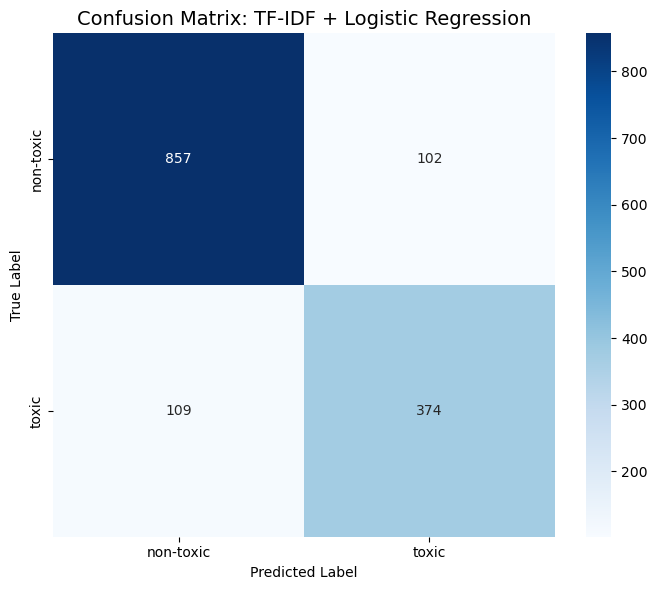

In [14]:
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["non-toxic", "toxic"],
    yticklabels=["non-toxic", "toxic"],
    cbar=True
)

plt.title("Confusion Matrix: TF-IDF + Logistic Regression", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

The confusion matrix shows that the model makes more errors on toxic comments than on non-toxic ones. Some toxic comments are classified as non-toxic, which is particularly important for toxic comment detection, where missing a toxic message is a critical type of error.

### Save results

In [15]:
metrics_df.to_csv("../reports/tfidf_logreg_metrics.csv", index=False)
results_df.to_csv("../reports/tfidf_logreg_hyperparams.csv", index=False)

### Save Model

In [16]:
import joblib

joblib.dump(best_model, "../experiments/tfidf_logreg.pkl")

['../experiments/tfidf_logreg.pkl']